# Force/torque data filtering

In this notebook, we briefly explore the pre-processed data to check for any anomalies; then, we find the best filter for the signal and save the the filtered dataset as a csv.

## 1. Import libraries and helper functions

In [16]:
import sys
sys.path.append('..')
from src import helpers, helpers_BW
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import  tqdm, tqdm_notebook


In [17]:
from importlib import reload 
reload(helpers)
reload(helpers_BW)

c:\Users\kmh\Documents\ZF_flight_ontogeny\notebooks\..\src\helpers.py:149: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('takeoff(\d+)', filename) # search for number after 'takeoff' in filename string


<module 'src.helpers_BW' from 'c:\\Users\\kmh\\Documents\\ZF_flight_ontogeny\\notebooks\\..\\src\\helpers_BW.py'>

## 2. Load dataset
Load the pre-processed force/torque data into a pandas dataframe. The force/torques are calibrated (with respect to time) and zero-centered. \
(See `FT_preprocessing.ipynb`)

In [3]:
FT_0centered_df = pd.read_csv("C:\\Users\\kmh\\Documents\\DATA\\FT_dataframe_subset_golden8_0centered.csv", index_col=0,
                     dtype = {'FlightID': int, 'Bird': str, 'Age': int, 'Landing': pd.Int64Dtype(), 'Note': str,'Frame': float, 
                              'Fx': float,'Fy': float,'Fz': float,'Tx': float,'Ty': float,'Tz': float})
FT_0centered_df

,FlightID,Bird,Age,Takeoff,Note,Frame,Fx,Fy,Fz,Tx,Ty,Tz,Time
0,1202001,greyR-blackL,20,1,NaN,1.000,-0.136233,0.013110,-0.019802,-0.408326,-8.571980,0.398708,-2.000000
1,1202001,greyR-blackL,20,1,NaN,1.125,-0.173155,-0.011407,-0.005773,-0.034080,-8.589821,0.400655,-1.998958
2,1202001,greyR-blackL,20,1,NaN,1.250,-0.151926,-0.002319,-0.012530,0.007764,-8.700545,0.114157,-1.997917
3,1202001,greyR-blackL,20,1,NaN,1.375,-0.163266,-0.014265,0.051036,0.332810,-8.671804,-0.446184,-1.996875
4,1202001,greyR-blackL,20,1,NaN,1.500,-0.153125,0.001482,0.049499,0.346638,-8.602175,-0.600892,-1.995833
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4986043,3710011,greenR-greenL,100,11,NaN,480.375,-0.003098,-0.001220,0.000054,-0.229946,-0.103484,0.015487,1.994792
4986044,3710011,greenR-greenL,100,11,NaN,480.500,0.003936,0.006126,0.081992,-0.092064,0.017600,-0.742358,1.995833
4986045,3710011,greenR-greenL,100,11,NaN,480.625,0.020633,0.007700,0.059689,0.063627,0.084555,-0.730582,1.996875
4986046,3710011,greenR-greenL,100,11,NaN,480.750,0.008992,-0.005182,0.071234,0.131222,0.060951,-0.843389,1.997917


### Description of axes
The diagram below shows the force & torque axes as the perch sensor outputs:

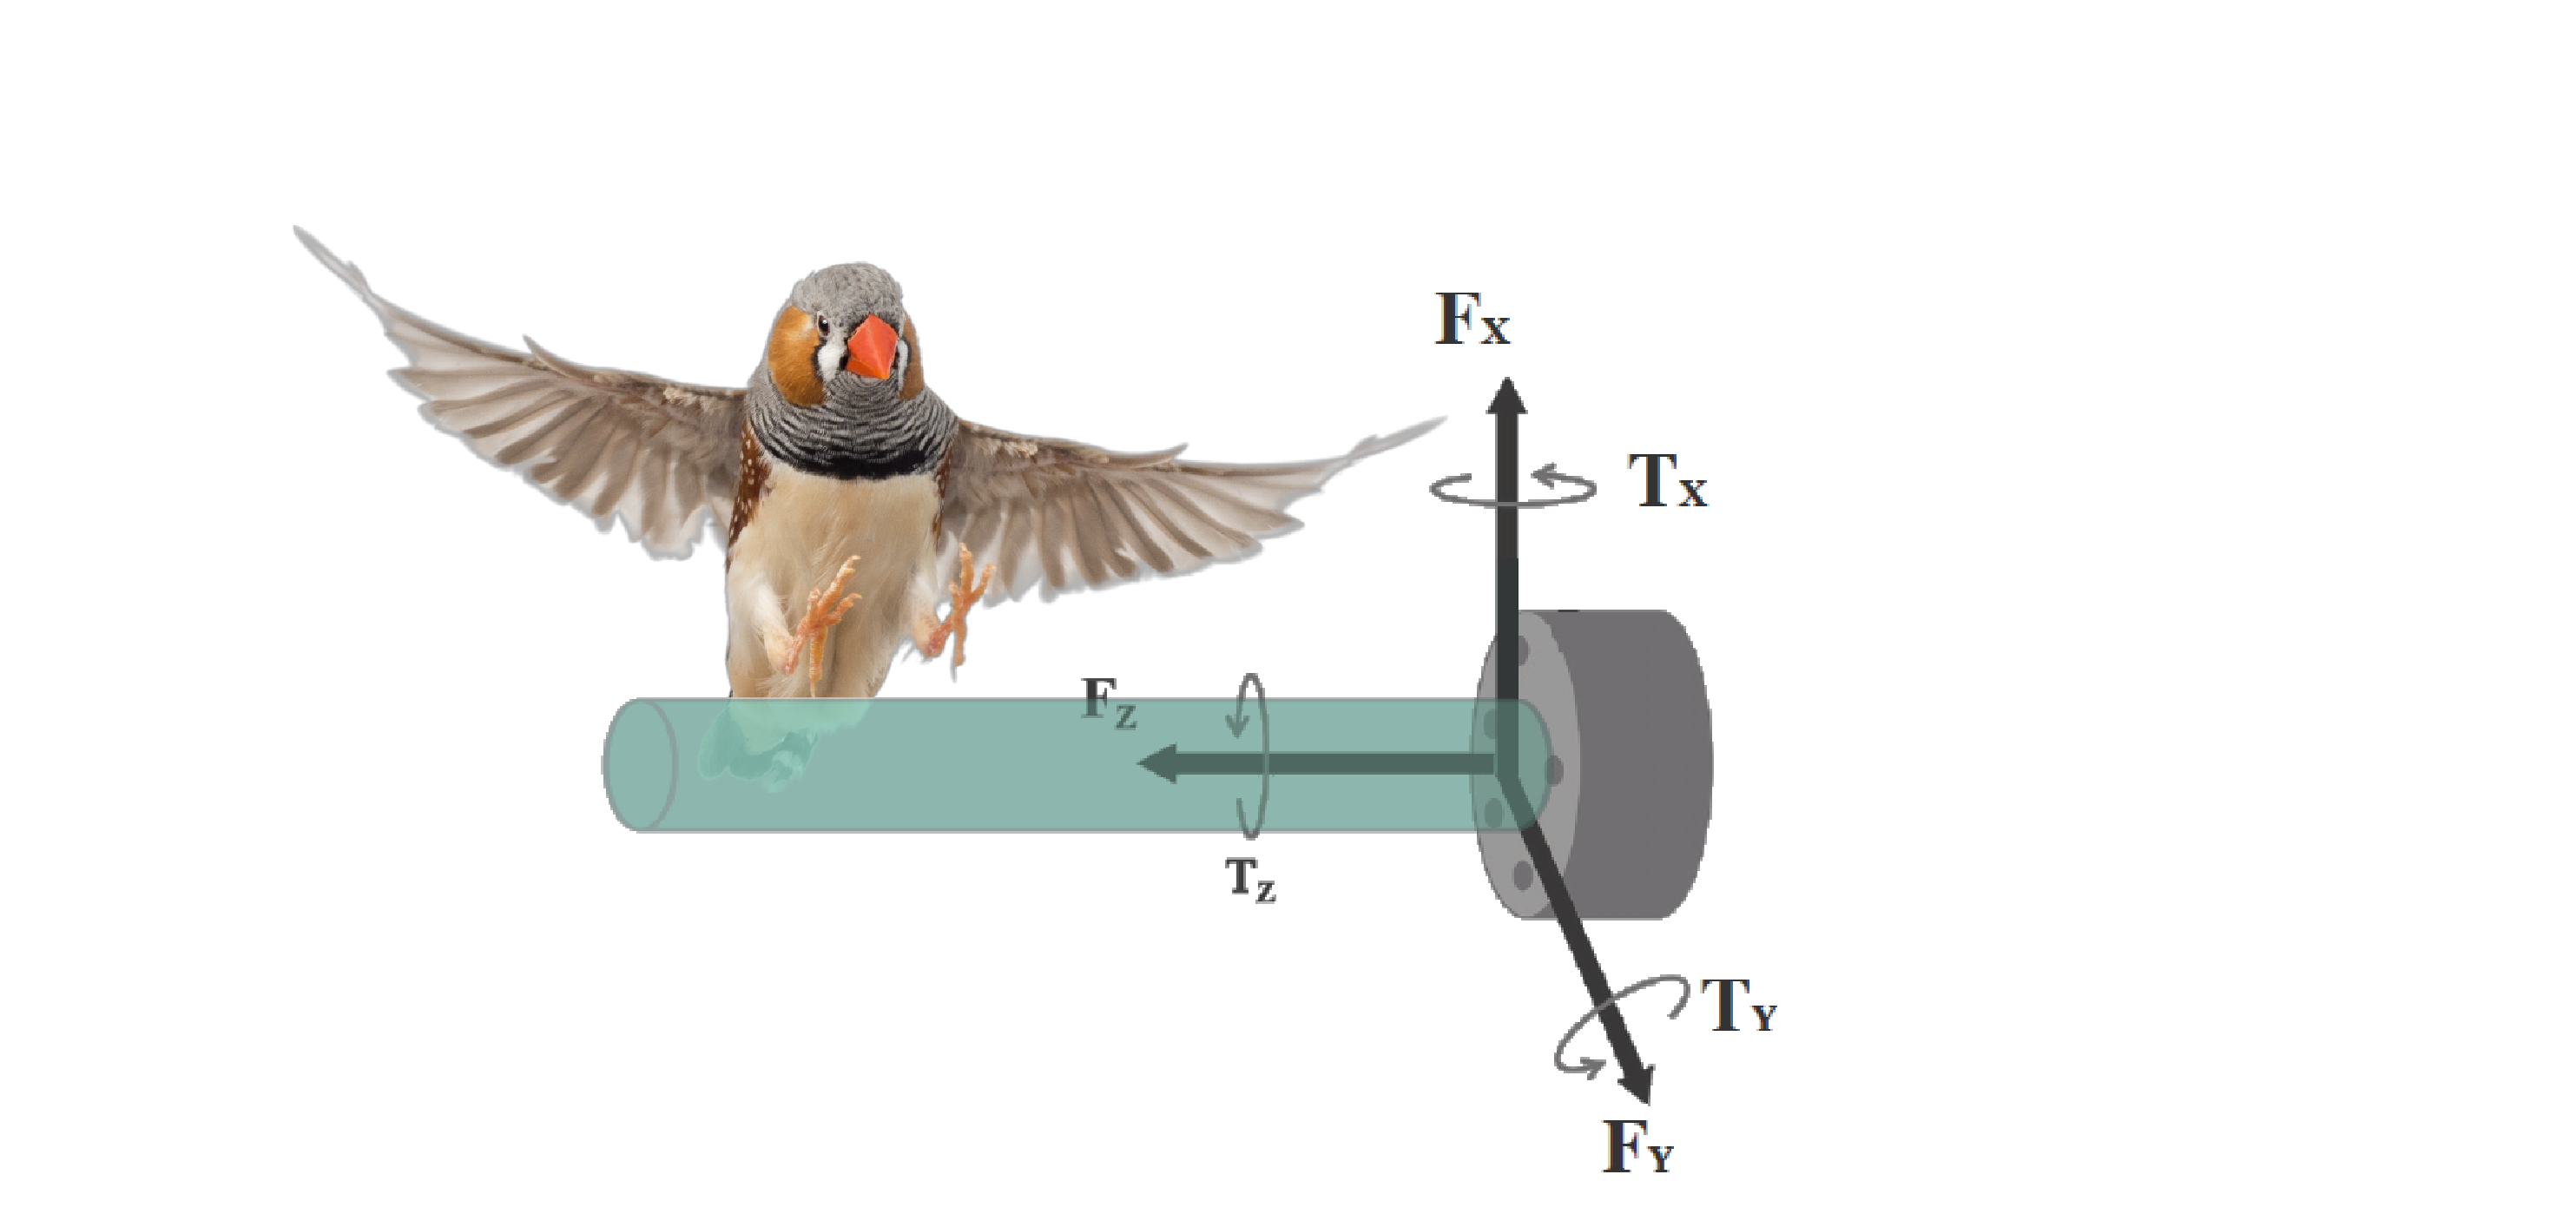

## 3. Check for anomalies

### 3.1 Global scatterplot to check that data looks good/ as expected:
Plots an overlay of all the perch sensor output (after calibration) for one of the axes (here Fx) vs the Time column.

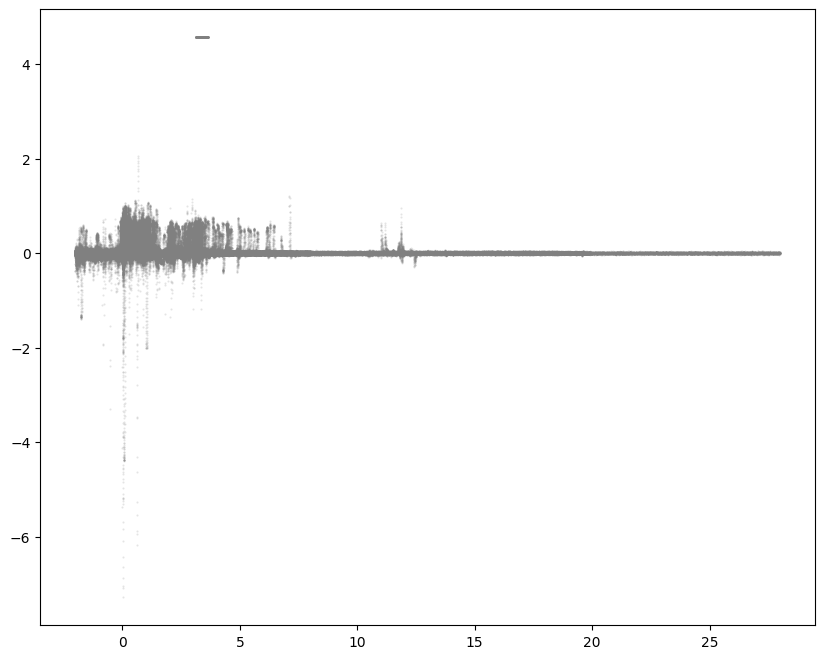

In [8]:
fig = plt.figure(figsize = (10,8))
ax = fig.subplots()
flights = FT_0centered_df['FlightID'].unique()
anomalies = []
for flight in flights:
    df = FT_0centered_df[FT_0centered_df['FlightID'] == flight]
    x = df['Time']
    y = df['Fy']
        
    ax.plot(x, y, marker='.', linewidth=0, color= 'grey', markersize=1, alpha = 0.2)
    
plt.show()

From this plot, we can see that: 
1. The time of impact (i.e. peak of force applied) does seem to align with t=0, at least for most landings. Hence, it seems reasonable to use frame #240 as the time of impact for future analysis.
2. Some of the landing data continues beyond 2 seconds after impact: this is due to inconsistency in the data collection, but shouldn't affect the analysis since the impact is still at t=2 seconds. 
3. Most of the post-impact (t>0 seconds) data is below F=0, as expected since Fx is the vertical component and hence shows the resting weight of the bird on the perch after landing. However, we can see that some of the data is centered around F=0 still after the impact. Would need to investigate the landings responsible to be certain, but this is likely due to a 'touch-and-go' landing where the bird touches the perch and flies away immediately AND/OR mislabeling of the landing files (in nexus). 

### 3.2 Make dataframe of max, min and mean amplitude of force/torques

In [9]:
flight_notes = FT_0centered_df.Note.unique()
df_description = helpers.describe_FTs(FT_0centered_df, start_Time=-2, stop_Time=15)

In [6]:
print("Here is a list of the 'labels' given to the different landings (in Nexus): \n ", flight_notes)

Here is a list of the 'labels' given to the different landings (in Nexus): 
  [nan 'landing']


Plot a matrix of histograms showing the distribution of \
the *mean* (+*std*), *min*, and *max* values of __Fx__, __Fy__, __Fz__, __Tx__, __Ty__, __Tz__ \
of each flight __before__ impact (frame 0 -> 200)

C:\Users\kmh\AppData\Local\Temp\ipykernel_29524\4053530179.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  hist = df_description.hist(ax=ax, layout = (6,4), bins=20)


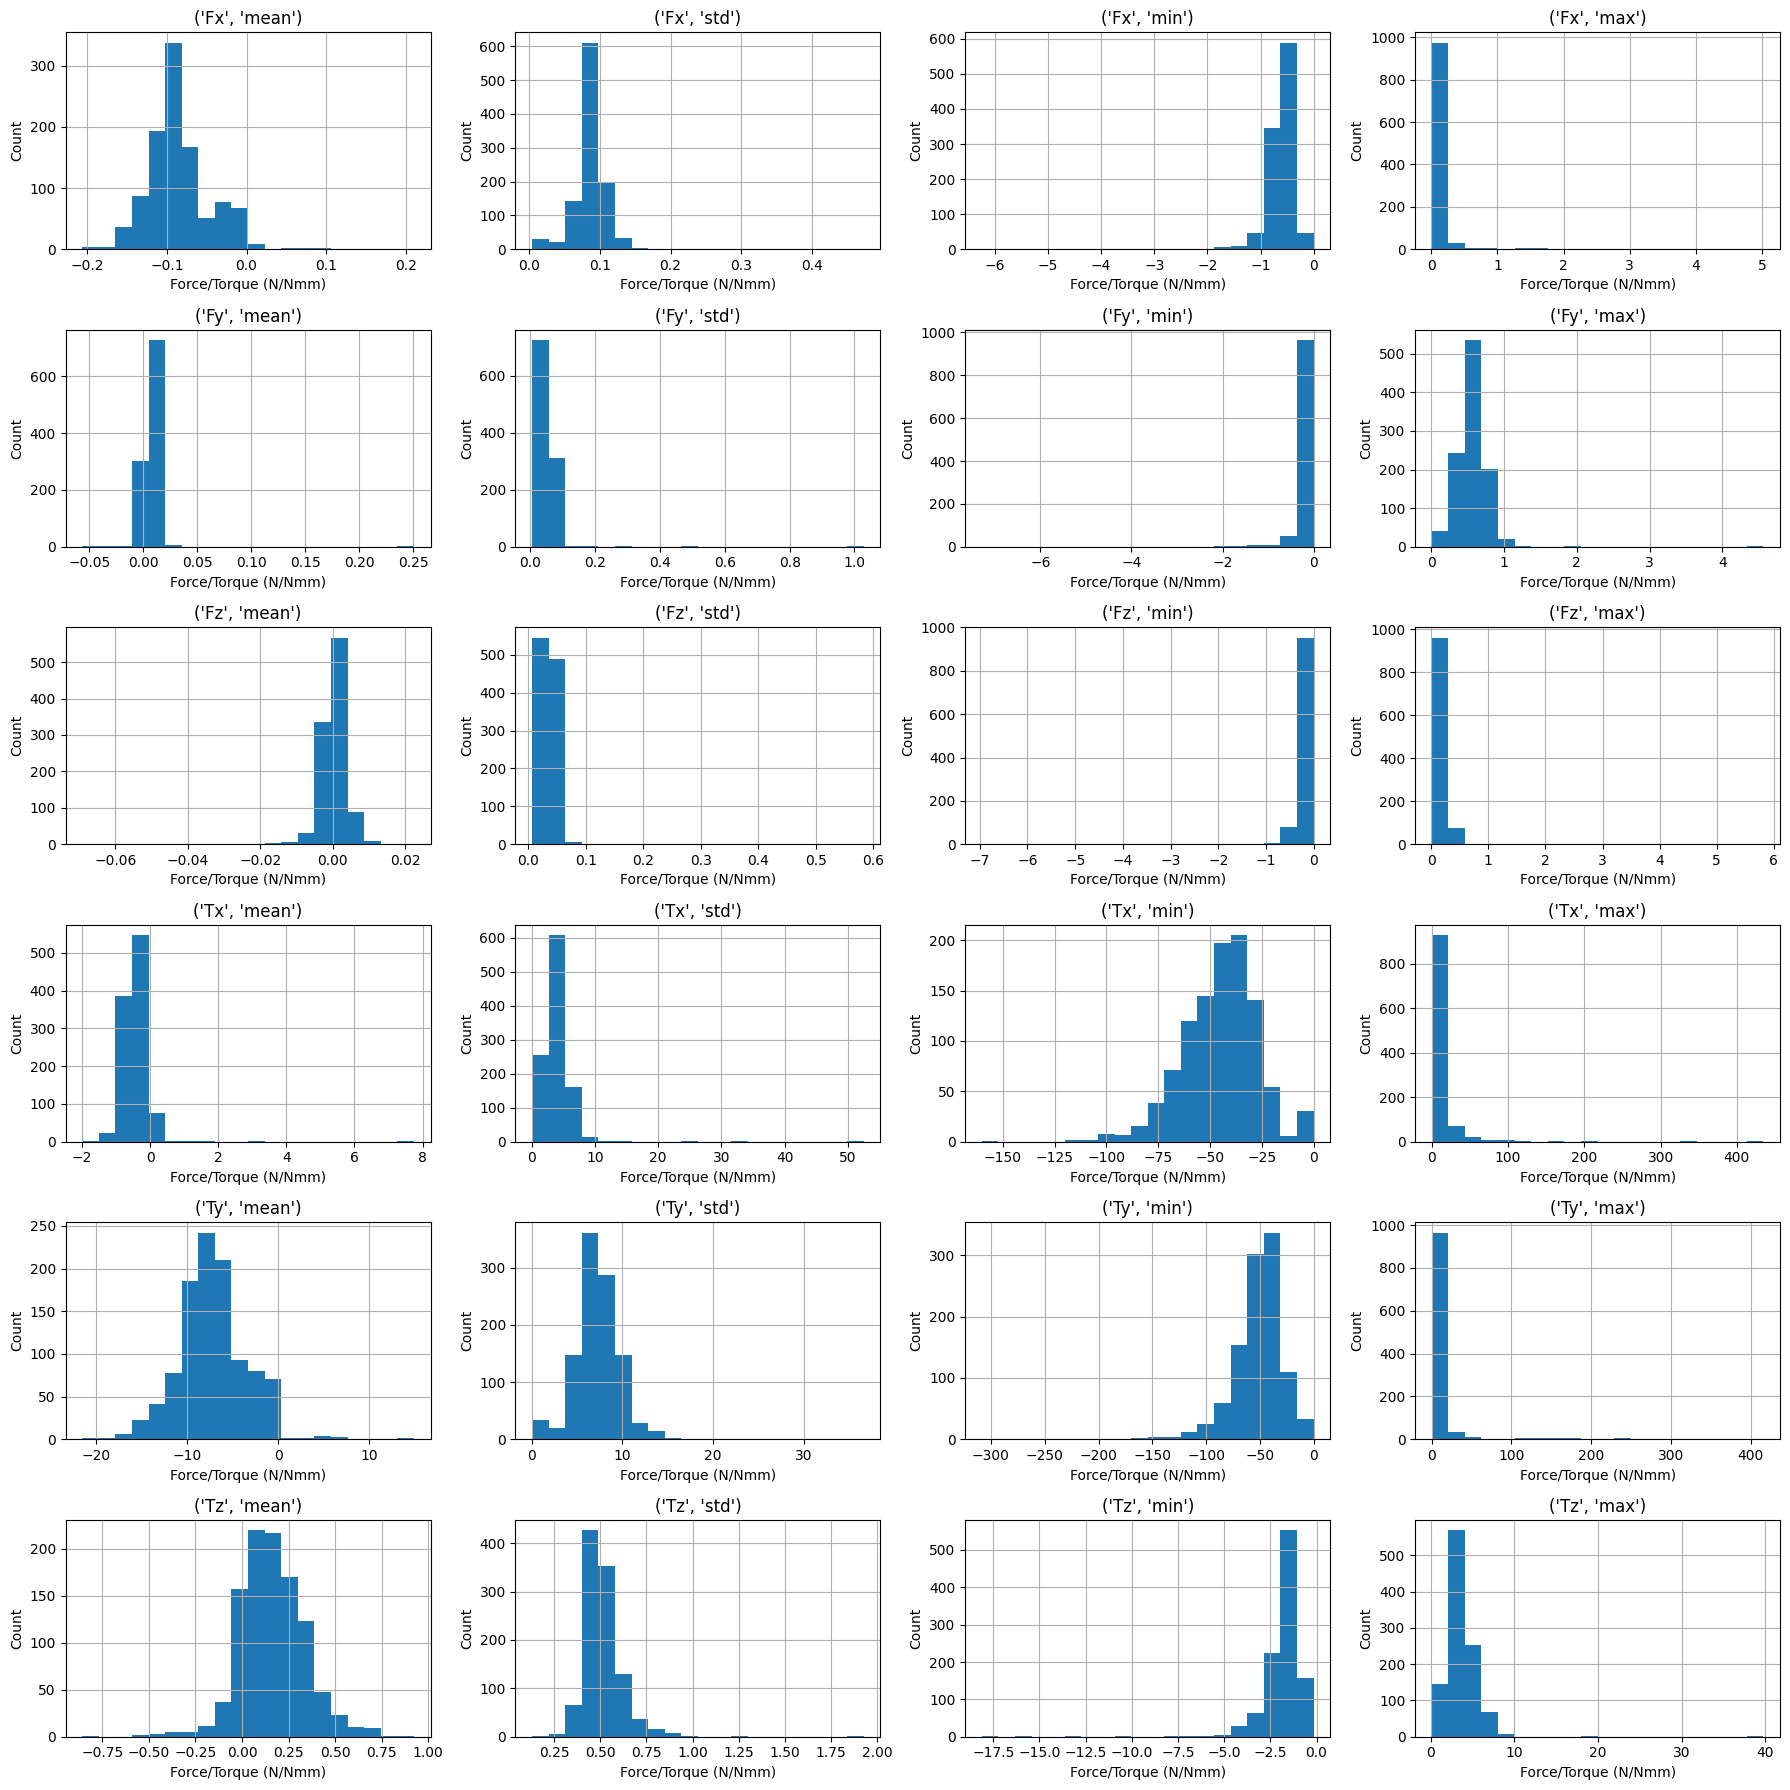

In [10]:
fig = plt.figure(figsize = (18, 18))
ax = fig.gca()
hist = df_description.hist(ax=ax, layout = (6,4), bins=20)
for ax in hist.flatten():
    ax.set_xlabel("Force/Torque (N/Nmm)")
    ax.set_ylabel("Count")
plt.tight_layout()

#### Observations -landing:
1. The means look normally distributed
2. Min and max distributions look fine, seem symmetric enough
3. Standard devs seem to be bimodal? _**What could cause this?**_

#### Observations -takeoff:
1. Everything looks pretty normal with max Fy around 0.6 N and Fx mean around -0.12 N, which would come down to 12g. 

## 4. Filter the force/torque signals
We need to filter the data to eliminate noise as much as possible.

### 4.1 Finding the best filter for this data
Roderick et al. (2019) used a Butterworth filter for their similar data (force/torques applied by parrotlets upon landing on a perch, obtained with an ATI Nano43 sensor).
> The Butterworth filter is a type of signal processing filter designed to have a frequency response that is as flat as possible in the passband (wikipedia).

------
 
#### Parameters to consider:
1. **Whether to apply the filter in one or both directions:** *Forward and reverse filter the signal [...] corrects for phase distortion introduced by a one-pass filter, though it does square the magnitude response in the process.* Source: octave.sourceforge.io. Chose to use both directions bc phase distortion might mess with the peak location? (not sure about this - Graham might have said to use both directions too, should check)

2. **Choosing the order of the filter:**  Roderick et al. (2019) used n=8 so using this for now. May need to check criteria later.

3. **Choosing the cutoff of the filter (in Hz):** Roderick et al. (2019) used f=100 Hz cutoff, but there seems to be noise below 100Hz for my data. Most noise in my data appears to be at 50Hz or above - refer to `FT_calibration.ipynb` for the FFT analysis - so we choose a `f = 45 Hz` cutoff. Zebra finch wingbeats are ~30Hz and perch natural frequency should be above 100Hz, so there shouldn't be significant loss of information with this cutoff.

\
*Note from scipy.signal documentation (docs.scipy.org):*
> The function `sosfiltfilt` (and filter design using `output='sos'`) should be preferred over `filtfilt` for most filtering tasks, as second-order sections have fewer numerical problems.

### 4.2 Apply the chosen Butterworth filter 
Call function to apply a Butterworth filter to the (zero-centered and calibrated) data in both the forward and reverse directions.

> Implementation: `apply_butterfilt` uses the `sosfiltfilt()` function from the `scipy.signal` library. 

Note: Using both forward and reverse directions (->`filtfilt`) **doubles** the order of the filter!

In [18]:
butter_df = helpers.apply_butterfilt_takeoff(FT_0centered_df, order=8, cutoff=45, columns=['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz'],calibration=False)

  0%|          | 0/1043 [00:00<?, ?it/s]

In [19]:
butter_df

,FlightID,Bird,Age,Takeoff,Note,Frame,Fx,Fy,Fz,Tx,Ty,Tz,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt
0,2302001,cyanR-blackL,20,1,NaN,1.000,-0.132588,-0.022100,-0.003362,0.504721,-12.001989,0.426949,-2.000000,-0.133255,-0.022654,-0.003628,0.503325,-12.003724,0.423088
1,2302001,cyanR-blackL,20,1,NaN,1.125,-0.144294,-0.004517,-0.007162,0.251551,-12.140376,0.815985,-1.998958,-0.133998,-0.019021,-0.006011,0.478074,-12.052556,0.478702
2,2302001,cyanR-blackL,20,1,NaN,1.250,-0.142735,0.001155,-0.030686,0.368279,-12.361784,0.716373,-1.997917,-0.134740,-0.015489,-0.007900,0.451907,-12.099235,0.526876
3,2302001,cyanR-blackL,20,1,NaN,1.375,-0.110659,0.002457,-0.001084,0.595999,-12.434521,1.010667,-1.996875,-0.135465,-0.012142,-0.009058,0.424115,-12.142261,0.563668
4,2302001,cyanR-blackL,20,1,NaN,1.500,-0.148954,-0.001278,-0.044893,0.900303,-12.034076,0.725827,-1.995833,-0.136151,-0.009050,-0.009325,0.394202,-12.180422,0.586289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4986043,3110012,yellowR-purpleL,100,12,NaN,480.375,0.011364,0.003787,0.062098,0.302371,0.110241,-0.977764,1.994792,-0.000186,-0.002269,0.011146,0.001101,-0.008791,-0.143599
4986044,3110012,yellowR-purpleL,100,12,NaN,480.500,-0.019019,-0.001511,0.062350,0.012327,0.068579,-0.753798,1.995833,0.000093,-0.003693,0.009046,-0.004161,-0.020824,-0.142148
4986045,3110012,yellowR-purpleL,100,12,NaN,480.625,-0.001996,0.007695,0.025075,0.044156,0.072565,-0.265843,1.996875,0.000374,-0.005369,0.005509,-0.011154,-0.034852,-0.128933
4986046,3110012,yellowR-purpleL,100,12,NaN,480.750,0.002773,-0.015782,0.007049,-0.155048,0.076524,-0.086700,1.997917,0.000652,-0.007234,0.000784,-0.019532,-0.050307,-0.105604


#### Plot an example landing to check filter is working:

In [26]:
bird = 'yellowR-purpleL'
age = 100
takeoff = 12

subset_df = butter_df[(butter_df['Bird'] == bird) & (butter_df['Age']==age) & (butter_df['Takeoff']==takeoff)]



In [27]:
subset_df

,FlightID,Bird,Age,Takeoff,Note,Frame,Fx,Fy,Fz,Tx,Ty,Tz,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt
4982208,3110012,yellowR-purpleL,100,12,NaN,1.000,-0.245419,0.002683,0.044915,-0.082486,-18.006358,-0.830152,-2.000000,-0.244877,0.002902,0.041892,-0.085666,-18.012109,-0.798614
4982209,3110012,yellowR-purpleL,100,12,NaN,1.125,-0.220876,0.013379,0.023886,-0.095879,-18.153051,-0.533151,-1.998958,-0.242820,0.003666,0.027860,-0.109059,-18.073565,-0.629038
4982210,3110012,yellowR-purpleL,100,12,NaN,1.250,-0.248325,0.000791,0.021463,-0.179393,-18.432489,-0.453549,-1.997917,-0.240778,0.004443,0.014642,-0.131445,-18.133742,-0.469402
4982211,3110012,yellowR-purpleL,100,12,NaN,1.375,-0.236386,0.008706,-0.024466,-0.086028,-18.118268,-0.115204,-1.996875,-0.238801,0.005200,0.002862,-0.152320,-18.191317,-0.327218
4982212,3110012,yellowR-purpleL,100,12,NaN,1.500,-0.237017,0.016350,-0.039915,-0.332196,-18.247176,0.099238,-1.995833,-0.236937,0.005903,-0.006946,-0.171271,-18.245080,-0.208856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4986043,3110012,yellowR-purpleL,100,12,NaN,480.375,0.011364,0.003787,0.062098,0.302371,0.110241,-0.977764,1.994792,-0.000186,-0.002269,0.011146,0.001101,-0.008791,-0.143599
4986044,3110012,yellowR-purpleL,100,12,NaN,480.500,-0.019019,-0.001511,0.062350,0.012327,0.068579,-0.753798,1.995833,0.000093,-0.003693,0.009046,-0.004161,-0.020824,-0.142148
4986045,3110012,yellowR-purpleL,100,12,NaN,480.625,-0.001996,0.007695,0.025075,0.044156,0.072565,-0.265843,1.996875,0.000374,-0.005369,0.005509,-0.011154,-0.034852,-0.128933
4986046,3110012,yellowR-purpleL,100,12,NaN,480.750,0.002773,-0.015782,0.007049,-0.155048,0.076524,-0.086700,1.997917,0.000652,-0.007234,0.000784,-0.019532,-0.050307,-0.105604


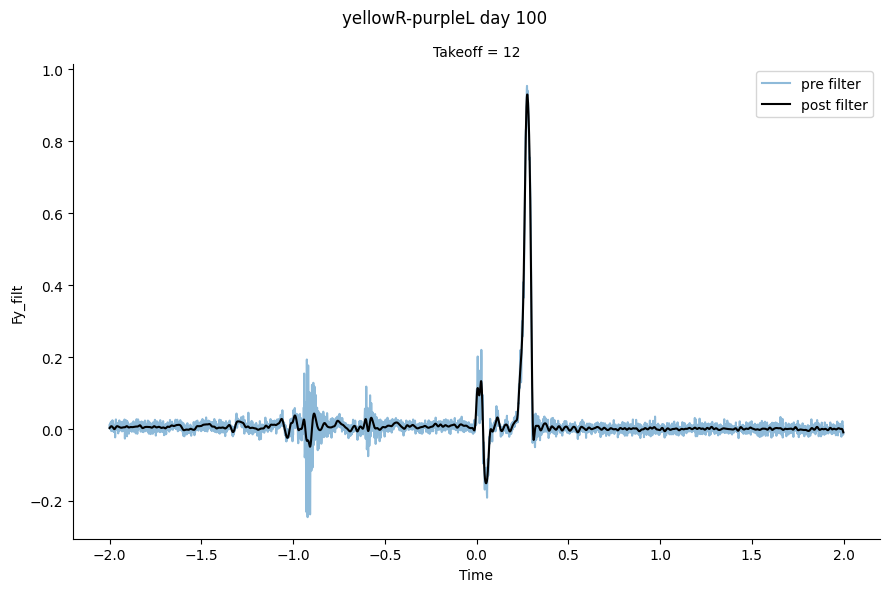

In [28]:
g = sns.FacetGrid(subset_df, row="Takeoff", height=6, aspect=1.5)
g.map(sns.lineplot, "Time", 'Fy', label='pre filter', alpha=0.5)
g.map(sns.lineplot, "Time", 'Fy_filt', color='black', label='post filter')
g.fig.suptitle(bird +" day "+str(age))
plt.legend(loc='upper right')
plt.tight_layout()

## 5. Save the filtered data
Save the filtered dataset as a csv file.

In [ ]:
butter_df.to_csv("C:\\Users\\kmh\\Documents\\DATA\\zebras_2025\\FT_dataframe_subset_golden8_butterfilt.csv", index=True)


In [ ]:
# Try spectogram analysis (fft over time) and compare signature of landings 
